# CITS4404 Deliverable 2 — AI Trading Bots

**Team 20**: Qiurong Chen (24558583), Yanchen Yu (24256987)

This notebook accompanies the Deliverable 2 report. It walks through the
entire experimental pipeline — from raw Bitcoin OHLCV data, through the
PDF §2.1 WMA building blocks, the two bot hypothesis spaces (B1: 2-D, B2:
~14-D), the §3 Evaluation back-test engine, the three optimisers
(Random Search, PSO, HHO), and the 5 × 3 × 2 experiment matrix —
and ends with the test-set generalisation results and the behavioural
analysis PDF §3 explicitly asks for.

**To reproduce from scratch**:
```bash
uv sync                                       # install deps
uv run python -m tradebot.data.load           # build train/test parquets
uv run python -m tradebot.experiments.run_matrix   # 30 runs (~1 min)
uv run python -m tradebot.experiments.analyze
uv run python -m tradebot.experiments.test_eval
uv run python -m tradebot.experiments.behavior
uv run python -m tradebot.experiments.figures
```

All figures shown below are loaded from `results/figures/` so the
notebook can be opened by a reviewer without re-running the experiment.

## 0. Setup

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

# Ensure the `tradebot` package on the repo root is importable
# regardless of where the notebook was launched.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
FIGS = REPO_ROOT / 'results' / 'figures'

def show(name):
    display(Image(filename=str(FIGS / name)))

## 1. Data (PDF §3 *Data*)

Kaggle's **Bitcoin Historical Dataset** (prasoonkottarathil/btcinusd).
PDF §3 fixes the split:
> *"You should optimise your agent on data prior to 2020, and preserve the
> data from 2020 onwards for final testing of your optimised bot."*

Train: 1860 days,  $    376.28 -> $  7,168.36
Test :   791 days,  $  7,178.68 -> $ 43,185.48


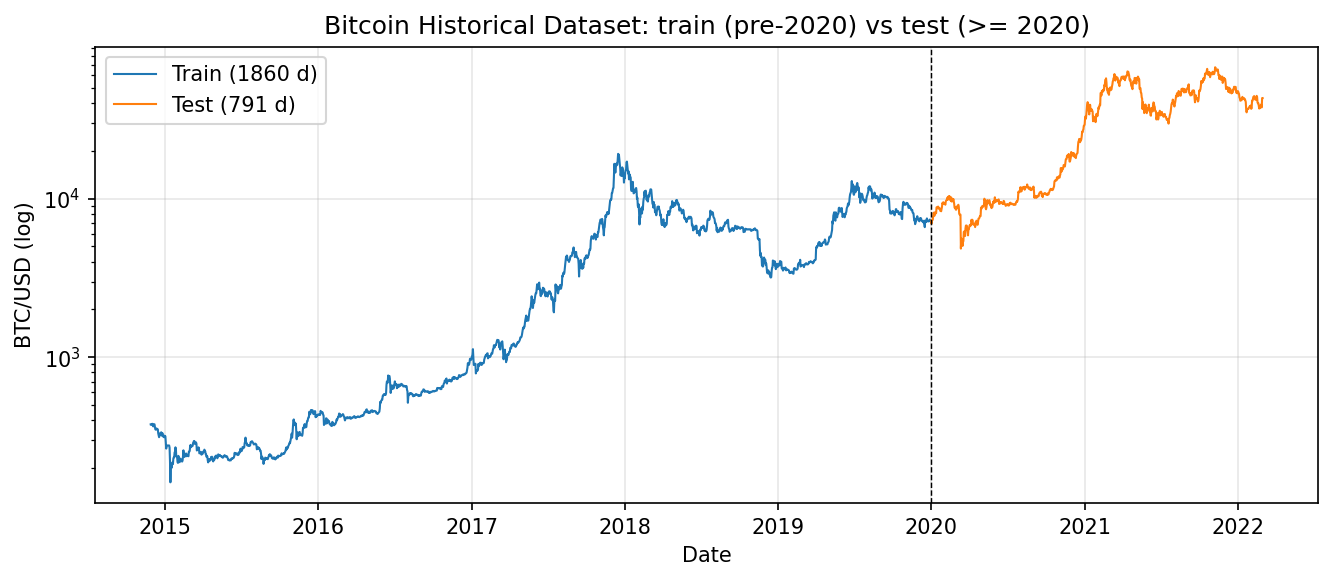

In [2]:
from tradebot.data.load import load_close, load_ohlcv

train = load_ohlcv('train')
test  = load_ohlcv('test')
print(f'Train: {len(train)} days,  ${train["close"].iloc[0]:>10,.2f} -> ${train["close"].iloc[-1]:>10,.2f}')
print(f'Test : {len(test):>5d} days,  ${test ["close"].iloc[0]:>10,.2f} -> ${test ["close"].iloc[-1]:>10,.2f}')
show('01_price_train_test.png')

## 2. WMA building blocks (PDF §2.1)

Equations (1)–(5) and the code listing in §2.1 are implemented verbatim in
`tradebot/bot/wma.py`. PDF Figure 3 (two-window SMA) and Figure 5
(SMA / LMA / EMA at the same window) are reproduced below.

SMA(5)   : [0.2 0.2 0.2 0.2 0.2]
LMA(5)   : [0.333 0.267 0.2   0.133 0.067]   (sum=1.000)
EMA(5,α=0.3): [0.3   0.21  0.147 0.103 0.072]   (sum=0.832)


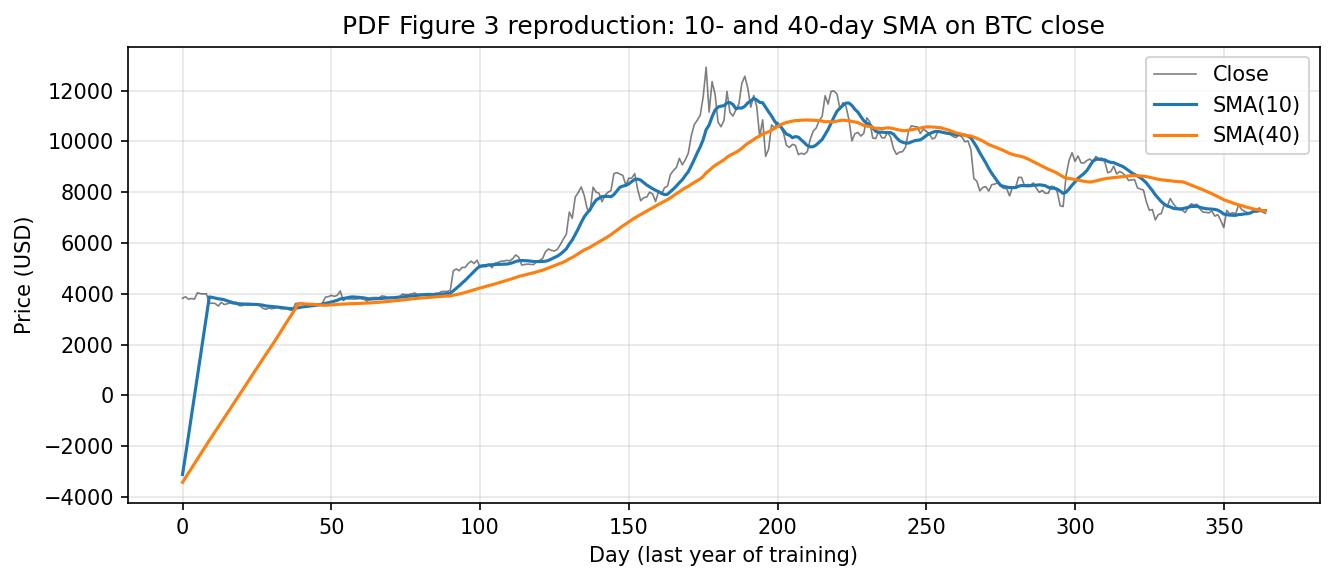

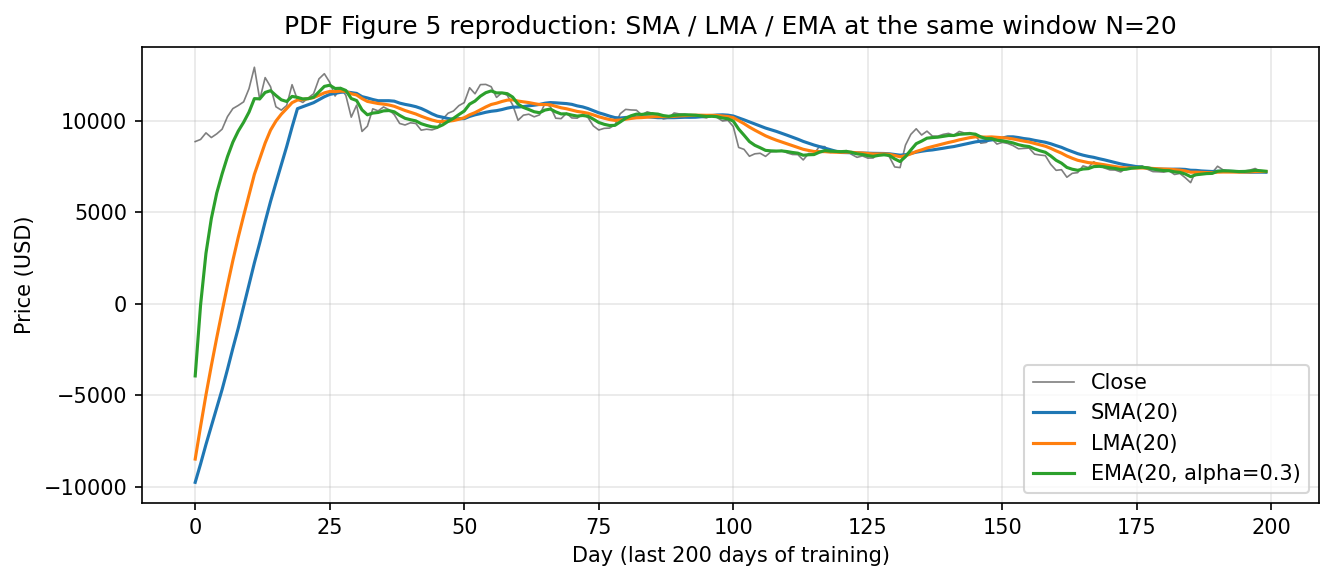

In [3]:
from tradebot.bot.wma import sma_filter, lma_filter, ema_filter, wma

# Three kernels at N=20:
print('SMA(5)   :', np.round(sma_filter(5),   3))
print('LMA(5)   :', np.round(lma_filter(5),   3), '  (sum=%.3f)' % lma_filter(5).sum())
print('EMA(5,α=0.3):', np.round(ema_filter(5, 0.3), 3), '  (sum=%.3f)' % ema_filter(5, 0.3).sum())

show('02_wma_sma_two_windows.png')
show('03_wma_three_kernels.png')

## 3. Bot hypothesis spaces (PDF §2.2/§2.3, §3 Eq.(7))

- **B1** — two SMAs + crossover (PDF §2.3 Figure 6 example, 2-D).
- **B2** — high/low components each `(w₁·SMA(d₁) + w₂·LMA(d₂) + w₃·EMA(d₃,α))/Σwᵢ` per
  PDF §3 Eq.(7); a crossover between the two compounds. 14-D.

In [4]:
from tradebot.bot.bots import BotB1, BotB2

for cls in (BotB1, BotB2):
    lo, hi = cls.bounds()
    print(f'{cls.NAME:<14s} N_PARAMS={cls.N_PARAMS:<3d}  range examples: lo={lo[:5]}... hi={hi[:5]}...')

B1_dual_sma    N_PARAMS=2    range examples: lo=[2. 2.]... hi=[300. 300.]...
B2_compound    N_PARAMS=14   range examples: lo=[0. 0. 0. 2. 2.]... hi=[  1.   1.   1. 200. 200.]...


## 4. Back-test engine (PDF §3 *Evaluation of Bots*)

All five PDF rules are encoded in `tradebot/bot/backtest.py`:
$1000 starting cash, 3% fee per transaction, final-day liquidation,
fitness = ending cash.

The closed-form **buy-and-hold baseline** below is the reference point
every optimised bot must beat to claim any value.

In [5]:
from tradebot.bot.backtest import backtest_detailed, INITIAL_CASH, FEE_RATE
from tradebot.experiments.test_eval import buy_and_hold

train_close = load_close('train')
test_close  = load_close('test')

print(f'INITIAL_CASH = ${INITIAL_CASH:.0f},  FEE_RATE = {FEE_RATE:.2%}')
print(f'Buy-and-hold on TRAIN: ${buy_and_hold(train_close):>10,.2f}')
print(f'Buy-and-hold on TEST : ${buy_and_hold(test_close):>10,.2f}')

INITIAL_CASH = $1000,  FEE_RATE = 3.00%
Buy-and-hold on TRAIN: $ 17,924.71
Buy-and-hold on TEST : $  5,660.26


## 5. Optimisers — fair-comparison framework

Three optimisers, all hand-written under PDF §3 *Rules of Engagement*:

- **Random Search** — single-state baseline (PDF "single-state algorithms").
- **PSO** — Kennedy & Eberhart 1995 + Shi & Eberhart 1998 inertia weight (D1 Synopsis 1).
- **HHO** — Heidari et al. 2019, 6-rule energy-gated update (D1 Synopsis 2).

The `Optimizer` base class wraps the user fitness in an `Objective`
accountant that **stops every algorithm at exactly `budget` evaluations**,
satisfying PDF §3's *"fixed number of evaluations"* fairness requirement.

In [6]:
from tradebot.optim.random_search import RandomSearch
from tradebot.optim.pso import PSO
from tradebot.optim.hho import HHO

for cls in (RandomSearch, PSO, HHO):
    print(f'{cls.NAME:<14s}  module={cls.__module__}')

RandomSearch    module=tradebot.optim.random_search
PSO             module=tradebot.optim.pso
HHO             module=tradebot.optim.hho


## 6. Experiment matrix — training set (Task #13)

30 runs: **3 algorithms × 2 bots × 5 seeds**, each consuming 5,000 fitness
evaluations. PDF §3 *Choosing Algorithms*: *"compare the outcome on a
fixed number of evaluations"*.

40 runs · 200,000 total evaluations


mean    std    min    max
bot         algorithm                               
B1_dual_sma GWO           57219   3482  50990  58776
            HHO           52383   6958  41802  57212
            PSO           57219   3482  50990  58776
            RandomSearch  55484   3414  50232  58776
B2_compound GWO           65424   6318  61840  76594
            HHO           52001   4557  45418  57522
            PSO           63651  12207  50046  77897
            RandomSearch  55323   3683  50714  59480

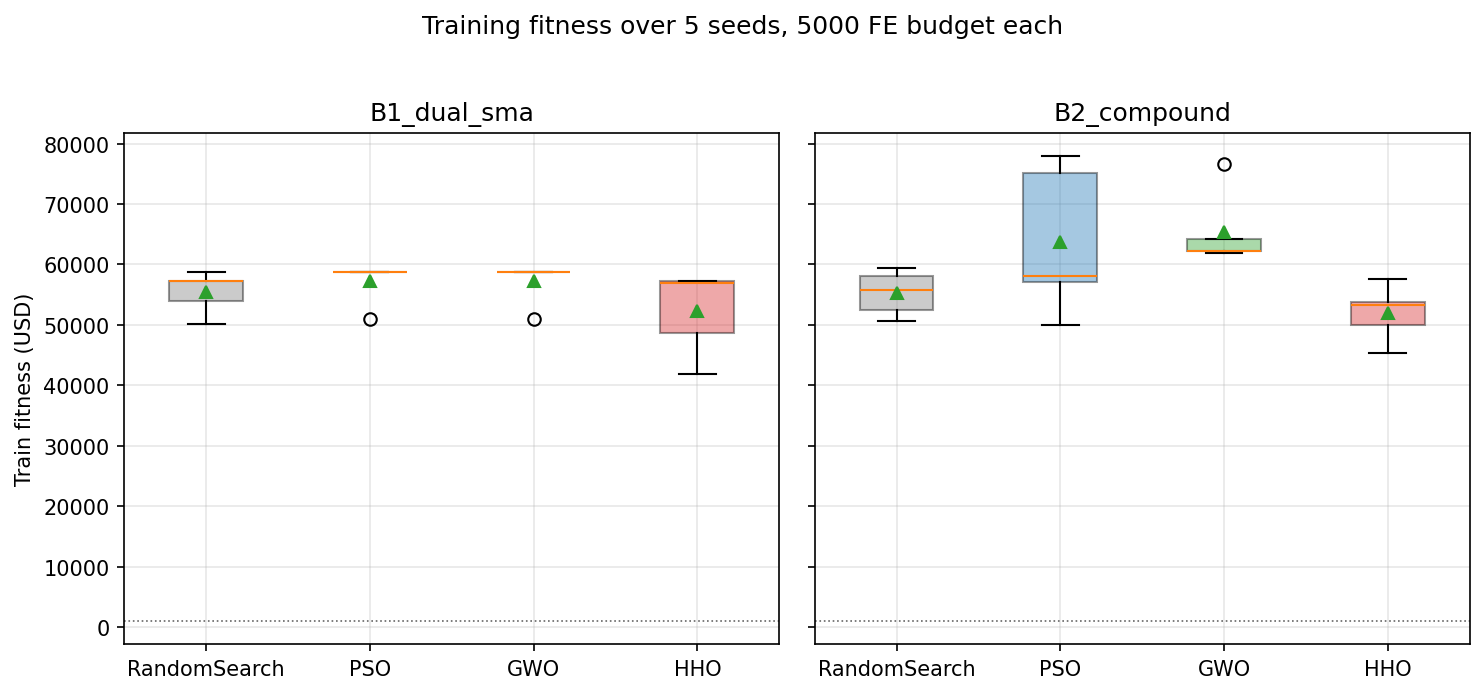

In [7]:
summary = pd.read_csv(REPO_ROOT / 'results' / 'summary.csv')
print(f'{len(summary)} runs · {summary["n_evaluations"].sum():,} total evaluations')

agg = (summary.groupby(['bot', 'algorithm'])['best_fitness']
       .agg(['mean', 'std', 'min', 'max']).round(0).astype(int))
display(agg)

show('04_train_fitness_boxplot.png')

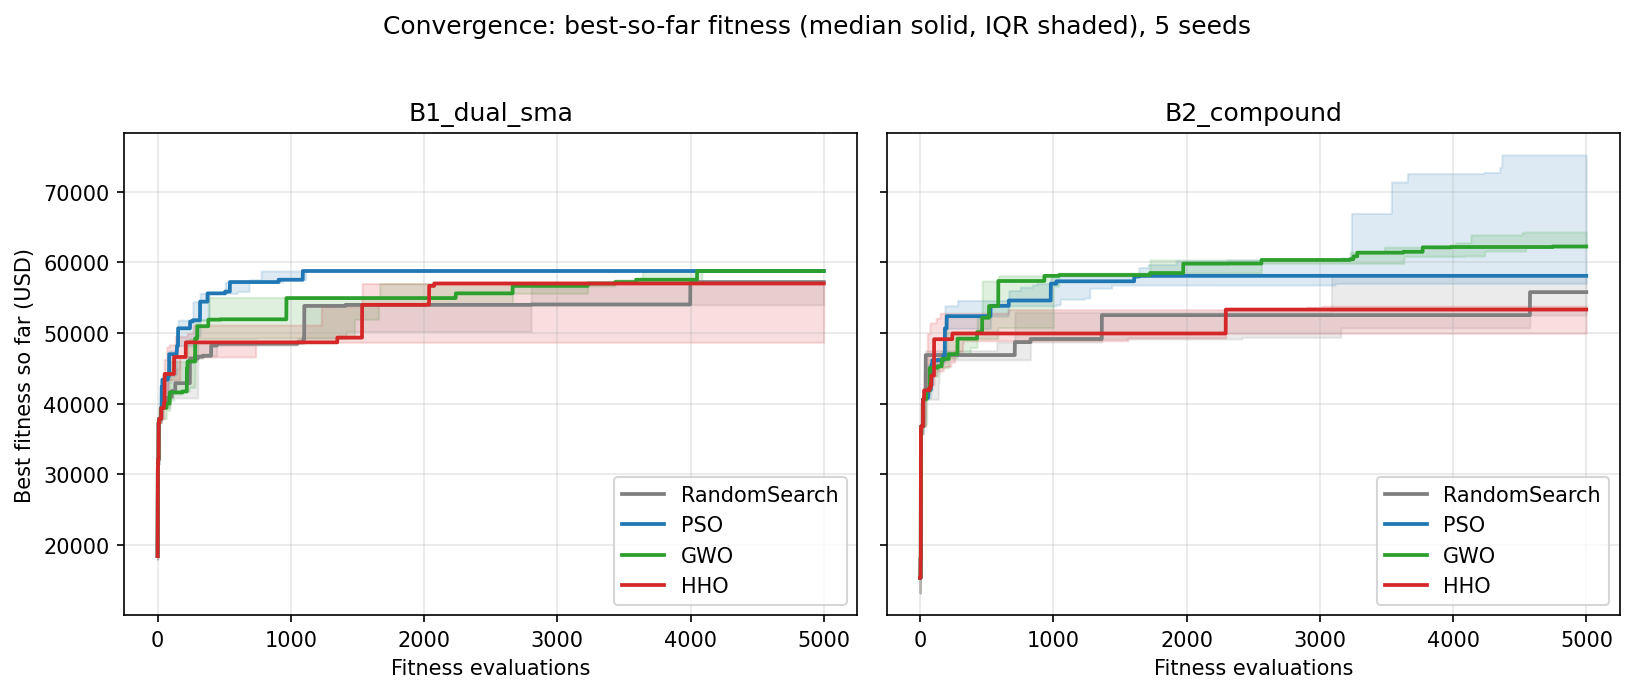


== B1_dual_sma == Mann-Whitney U p-values (two-sided)
  GWO_vs_HHO                 p = 0.0472 *
  GWO_vs_PSO                 p = 1.0000
  GWO_vs_RandomSearch        p = 0.1745
  HHO_vs_PSO                 p = 0.0472 *
  HHO_vs_RandomSearch        p = 0.3472
  PSO_vs_RandomSearch        p = 0.1745

== B2_compound == Mann-Whitney U p-values (two-sided)
  GWO_vs_HHO                 p = 0.0090 *
  GWO_vs_PSO                 p = 0.4647
  GWO_vs_RandomSearch        p = 0.0090 *
  HHO_vs_PSO                 p = 0.0758
  HHO_vs_RandomSearch        p = 0.2506
  PSO_vs_RandomSearch        p = 0.4647


In [8]:
show('05_convergence_curves.png')

stats = json.loads((REPO_ROOT / 'results' / 'stats.json').read_text())
for bot, block in stats['per_bot'].items():
    print(f'\n== {bot} == Mann-Whitney U p-values (two-sided)')
    for pair, p in block['mannwhitneyu_p_two_sided'].items():
        mark = ' *' if p < 0.05 else ''
        print(f'  {pair:<26s} p = {p:.4f}{mark}')

## 7. Generalisation — test set (Task #14)

Each (algorithm, bot, seed) best-on-train bot is re-deployed cold on
2020-01-01 and back-tested on the full 2020–2022 test split. Compared
against the buy-and-hold baseline of \$5,660.

train_fitness  test_fitness  generalisation_gap
bot         algorithm                                                    
B1_dual_sma GWO                   57219          1642               55576
            HHO                   52383          2240               50143
            PSO                   57219          1642               55576
            RandomSearch          55484          1637               53846
B2_compound GWO                   65424           895               64528
            HHO                   52001          1199               50802
            PSO                   63651           836               62815
            RandomSearch          55323          1144               54180

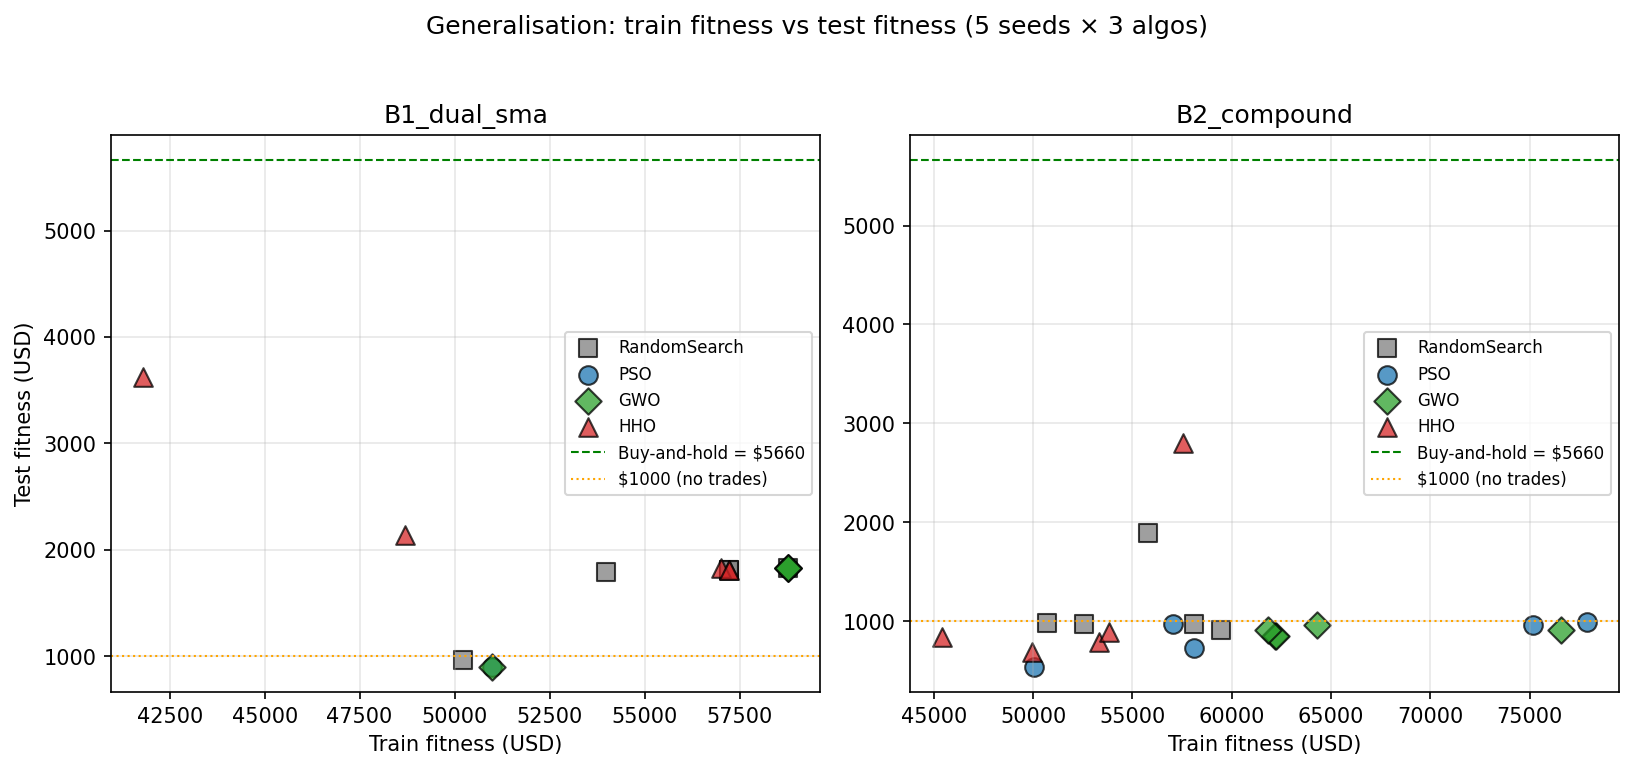

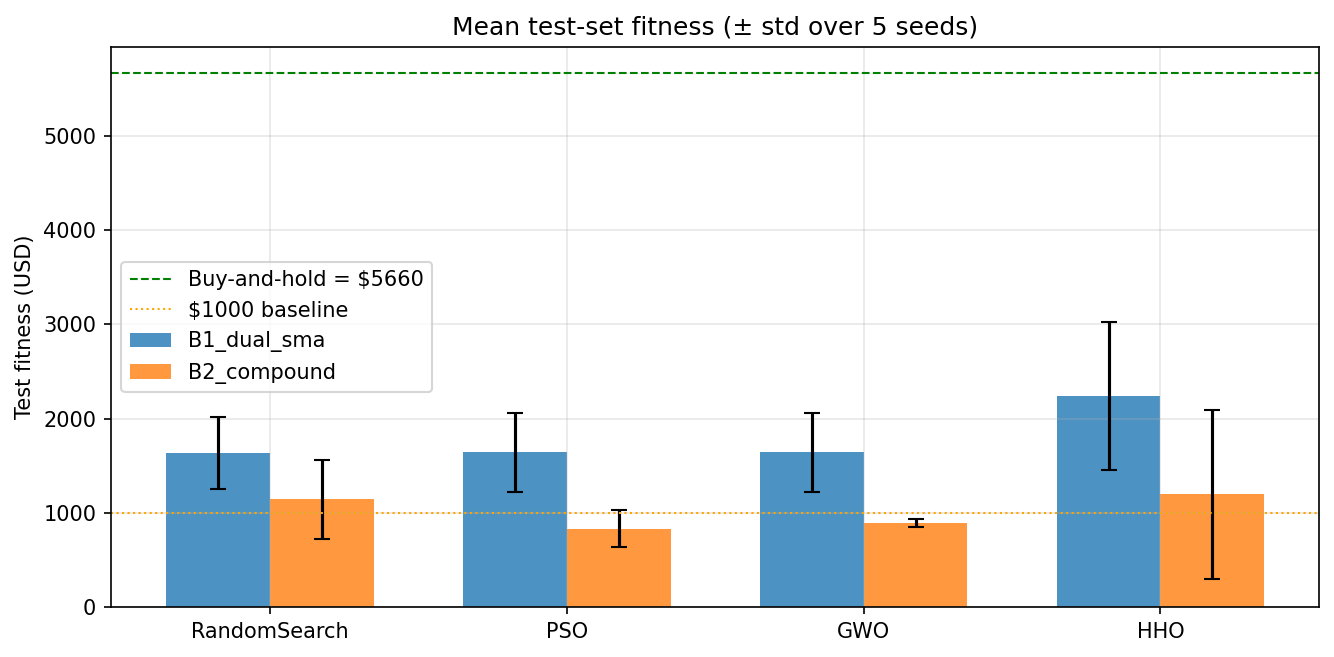

In [9]:
test_results = pd.read_csv(REPO_ROOT / 'results' / 'test_results.csv')
agg_test = (test_results.groupby(['bot', 'algorithm'])
            [['train_fitness', 'test_fitness', 'generalisation_gap']]
            .mean().round(0).astype(int))
display(agg_test)

show('06_train_test_scatter.png')
show('07_test_fitness_bar.png')

## 8. Behavioural analysis (PDF §3 explicit prompt)

> *"It will be interesting to look after optimising to see how much
> weight the bot gives to each component — does it consistently favour
> one or continue to draw from all three."*

We normalise each B2 best-x's (w₁, w₂, w₃) for the HIGH and LOW
components, then aggregate across seeds per algorithm. HHI = Σwᵢ² is the
Herfindahl–Hirschman concentration index: 1/3 = perfectly even,
1.0 = single-WMA dominance.

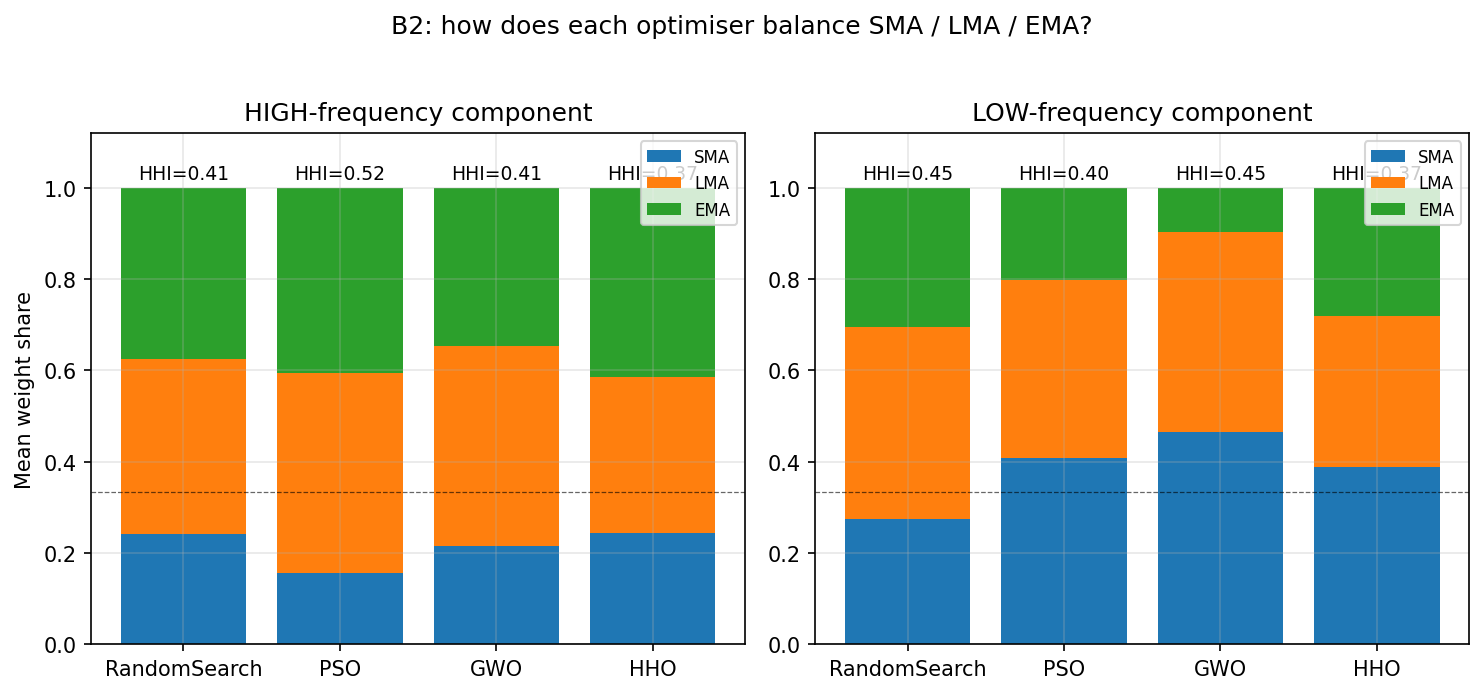

,algorithm,side,SMA,LMA,EMA,HHI,winners
0,GWO,HIGH,21.6%,43.6%,34.7%,0.408,"{'SMA': 0, 'LMA': 3, 'EMA': 2}"
1,GWO,LOW,46.5%,43.8%,9.8%,0.449,"{'SMA': 4, 'LMA': 1, 'EMA': 0}"
2,HHO,HIGH,24.3%,34.2%,41.5%,0.372,"{'SMA': 1, 'LMA': 1, 'EMA': 3}"
3,HHO,LOW,38.8%,33.2%,28.1%,0.373,"{'SMA': 2, 'LMA': 3, 'EMA': 0}"
4,PSO,HIGH,15.6%,43.9%,40.5%,0.521,"{'SMA': 0, 'LMA': 3, 'EMA': 2}"
5,PSO,LOW,40.8%,39.1%,20.1%,0.399,"{'SMA': 3, 'LMA': 1, 'EMA': 1}"
6,RandomSearch,HIGH,24.2%,38.3%,37.5%,0.411,"{'SMA': 1, 'LMA': 2, 'EMA': 2}"
7,RandomSearch,LOW,27.6%,42.1%,30.4%,0.451,"{'SMA': 1, 'LMA': 3, 'EMA': 1}"


In [10]:
behavior = json.loads((REPO_ROOT / 'results' / 'behavior.json').read_text())

show('08_b2_weight_shares.png')

rows = []
for algo, block in behavior['per_algorithm'].items():
    for side in ('high', 'low'):
        shares = block[f'{side}_mean_shares']
        rows.append({
            'algorithm': algo, 'side': side.upper(),
            'SMA': f"{shares['SMA']:.1%}", 'LMA': f"{shares['LMA']:.1%}", 'EMA': f"{shares['EMA']:.1%}",
            'HHI': round(block[f'{side}_mean_hhi'], 3),
            'winners': block[f'{side}_winner_counts'],
        })
display(pd.DataFrame(rows))

## 9. Best-of-run bot — trade overlay

The highest-train-fitness bot (PSO on B2, seed=4) collects \$77,897 on the
training set with just three buy/sell pairs — and only \$992 on the test
set, a textbook illustration of regime-dependent over-fitting. PDF §3
warned about this explicitly: *"success on past sequences of data does
not guarantee a strategy will be successful on future sequences"*.

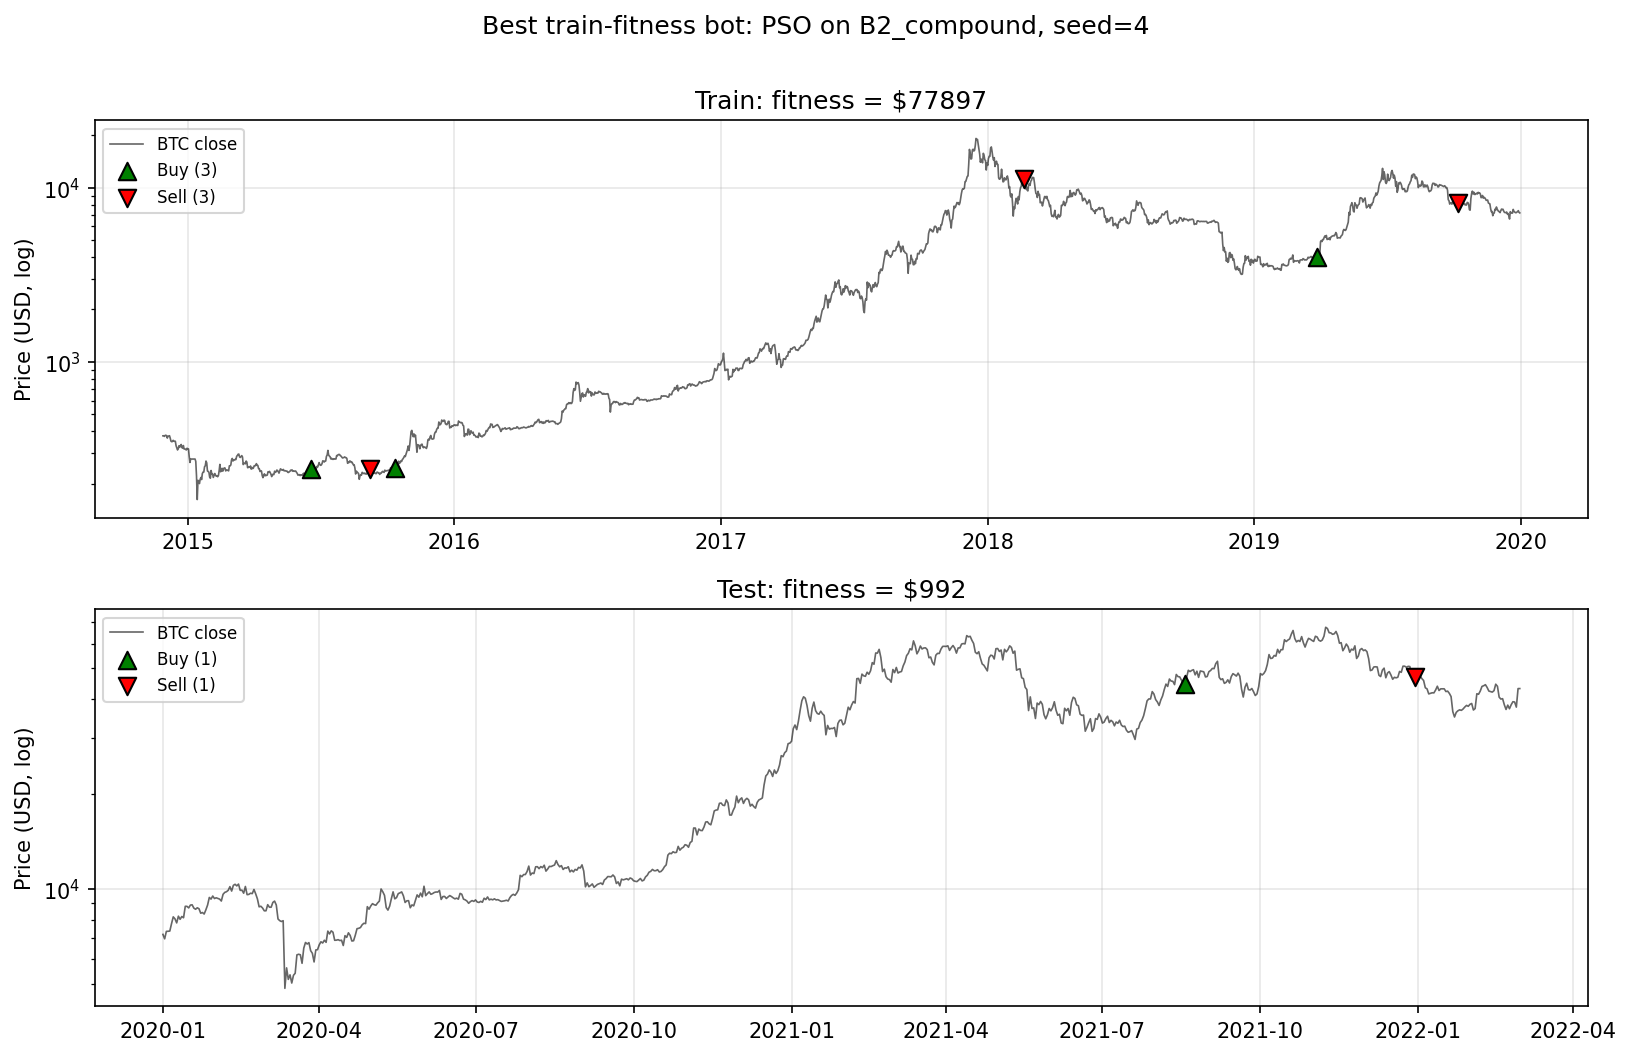

In [11]:
show('09_best_bot_trades.png')

## 10. Compliance & reproducibility

**PDF §3 *Rules of Engagement* compliance**:
1. No external bot code — every component in `tradebot/bot/` is hand-written.
2. No general optimisation libraries — every algorithm in `tradebot/optim/` is
   hand-written; the only scientific-Python deps are numpy / pandas / matplotlib.
3. Algorithm citations: PSO (Kennedy & Eberhart 1995, Shi & Eberhart 1998),
   HHO (Heidari et al. 2019) appear in source-file headers, in the report,
   and will appear in the video presentation.

**Test coverage**: 214 unit tests across the WMA module, back-test engine,
signal generation, bot classes, optimiser base, all three algorithms, the
experiment driver, the test-set evaluation, the behavioural analysis, and
the figure pipeline.

```bash
uv run pytest tests/  # 214 passed
```